# Polynomial Regression with Easy Explanations

This notebook teaches Polynomial Regression in a simple step-by-step way.

Dataset used: **Diabetes dataset** from scikit-learn (built-in).

Why this dataset?
- It is built into scikit-learn (no manual download needed)
- It is a real regression dataset
- It works well for comparing linear vs polynomial behavior

## Easy English Terms (Quick Glossary)

- Linear Regression: fits a straight line.
- Polynomial Regression: fits a curve by adding powers like $x^2$, $x^3$.
- Degree: the highest power used in polynomial features.
- Underfitting: model is too simple.
- Overfitting: model learns noise and performs worse on new data.
- RMSE: average prediction error in target units.
- R2: goodness of fit (closer to 1 is better).
- Pipeline: fixed sequence of preprocessing + model steps.

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Step 1: Load Built-in Data

We load the diabetes dataset directly from scikit-learn.

Target column: `target` (a continuous value), so this is a regression task.

In [71]:
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame.copy()

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (442, 11)
Columns: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## Step 2: Choose One Feature for Clear Curve Visualization

For easy plotting, we use one feature: **BMI**.

- Input feature: `bmi`
- Output target: `target`

In [72]:
feature_name = 'bmi'
X = df[[feature_name]].values
y = df['target'].values

print('X shape:', X.shape)
print('y shape:', y.shape)
print('First 5 X values:', X[:5].ravel())

X shape: (442, 1)
y shape: (442,)
First 5 X values: [ 0.06169621 -0.05147406  0.04445121 -0.01159501 -0.03638469]


## Step 3: Split Data into Train and Test Sets

- Training data: teaches the model
- Testing data: checks performance on unseen samples

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])

Train size: 353
Test size: 89


## Step 4: Baseline Linear Regression

First we train a simple linear model (straight line). This gives us a baseline to compare against polynomial regression.

In [74]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

print('Linear model trained.')

Linear model trained.


## Step 5: Polynomial Degree Search

We test degrees 2 to 5 and choose the one with the lowest RMSE on test data.

In [75]:
degree_candidates = [2, 3, 4, 5]
search_rows = []

for degree in degree_candidates:
    poly_candidate = Pipeline([
        ('poly_features', PolynomialFeatures(degree=degree, include_bias=False)),
        ('model', LinearRegression())
    ])

    poly_candidate.fit(X_train, y_train)
    y_pred_candidate = poly_candidate.predict(X_test)

    rmse_candidate = np.sqrt(mean_squared_error(y_test, y_pred_candidate))
    r2_candidate = r2_score(y_test, y_pred_candidate)

    search_rows.append({
        'Degree': degree,
        'RMSE': rmse_candidate,
        'R2': r2_candidate
    })

degree_results = pd.DataFrame(search_rows).sort_values('RMSE').reset_index(drop=True)
degree_results

,Degree,RMSE,R2
0,3,63.752987,0.232856
1,2,63.914204,0.228972
2,5,63.920619,0.228817
3,4,65.008806,0.202336


In [76]:
best_degree = int(degree_results.loc[0, 'Degree'])

best_poly_model = Pipeline([
    ('poly_features', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('model', LinearRegression())
])

best_poly_model.fit(X_train, y_train)
y_pred_poly = best_poly_model.predict(X_test)

print('Best polynomial degree:', best_degree)

Best polynomial degree: 3


## Step 6: Compare Important Scores

We compare linear vs best polynomial model using:
- MAE
- MSE
- RMSE
- R2

In [77]:
def regression_scores(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

mae_lin, mse_lin, rmse_lin, r2_lin = regression_scores(y_test, y_pred_linear)
mae_poly, mse_poly, rmse_poly, r2_poly = regression_scores(y_test, y_pred_poly)

scores_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Linear Regression': [mae_lin, mse_lin, rmse_lin, r2_lin],
    f'Polynomial (degree={best_degree})': [mae_poly, mse_poly, rmse_poly, r2_poly]
})

scores_df

,Metric,Linear Regression,Polynomial (degree=3)
0,MAE,52.259976,52.181400
1,MSE,4061.825928,4064.443384
2,RMSE,63.732456,63.752987
3,R2,0.233350,0.232856


## Step 7: Visualize Curves, Residuals, and Key Scores

Charts shown below:
1. Data + fitted curves
2. Residual comparison
3. Key score bar chart

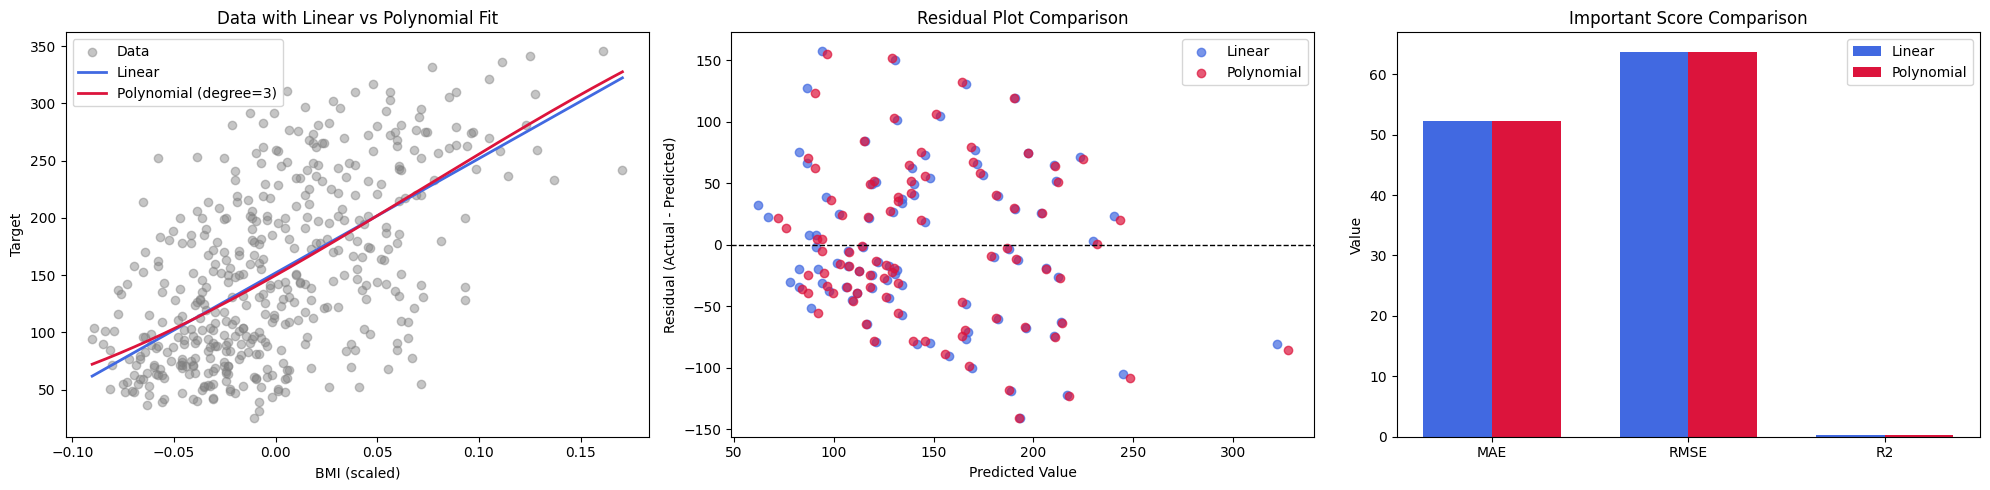

In [78]:
# Smooth x values for drawing clean model curves
X_curve = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_curve_linear = linear_model.predict(X_curve)
y_curve_poly = best_poly_model.predict(X_curve)

residual_linear = y_test - y_pred_linear
residual_poly = y_test - y_pred_poly

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1) Data and fitted curves
axes[0].scatter(X, y, color='gray', alpha=0.45, label='Data')
axes[0].plot(X_curve, y_curve_linear, color='royalblue', linewidth=2, label='Linear')
axes[0].plot(X_curve, y_curve_poly, color='crimson', linewidth=2, label=f'Polynomial (degree={best_degree})')
axes[0].set_title('Data with Linear vs Polynomial Fit')
axes[0].set_xlabel('BMI (scaled)')
axes[0].set_ylabel('Target')
axes[0].legend()

# 2) Residual comparison
axes[1].scatter(y_pred_linear, residual_linear, color='royalblue', alpha=0.7, label='Linear')
axes[1].scatter(y_pred_poly, residual_poly, color='crimson', alpha=0.7, label='Polynomial')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Residual Plot Comparison')
axes[1].set_xlabel('Predicted Value')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].legend()

# 3) Key score bars (lower is better for MAE/RMSE, higher is better for R2)
metric_names = ['MAE', 'RMSE', 'R2']
linear_vals = [mae_lin, rmse_lin, r2_lin]
poly_vals = [mae_poly, rmse_poly, r2_poly]

x_pos = np.arange(len(metric_names))
bar_width = 0.35

axes[2].bar(x_pos - bar_width / 2, linear_vals, width=bar_width, color='royalblue', label='Linear')
axes[2].bar(x_pos + bar_width / 2, poly_vals, width=bar_width, color='crimson', label='Polynomial')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(metric_names)
axes[2].set_title('Important Score Comparison')
axes[2].set_ylabel('Value')
axes[2].legend()

plt.tight_layout()
plt.show()

## Step 8: Make a Single Prediction

Example: predict target value for one BMI input.

`predict()` needs 2D input format, so we pass `[[value]]`.

In [10]:
sample_bmi = 0.05

linear_prediction = linear_model.predict([[sample_bmi]])[0]
poly_prediction = best_poly_model.predict([[sample_bmi]])[0]

print(f'Input BMI value: {sample_bmi}')
print(f'Linear prediction: {linear_prediction:.2f}')
print(f'Polynomial prediction (degree={best_degree}): {poly_prediction:.2f}')

Input BMI value: 0.05
Linear prediction: 201.93
Polynomial prediction (degree=3): 201.97


In [63]:
x = np.linspace(0,10,100)

y = x**2 + 0.1 * np.random.normal(size=x.shape)

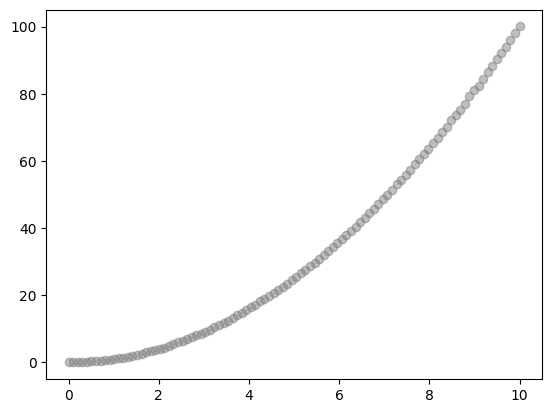

In [64]:
plt.scatter(x, y, color='gray', alpha=0.5, label='Data')

In [65]:
df = pd.DataFrame({
    'x': x,
    'y': y
})

df


,x,y
0,0.00000,0.091922
1,0.10101,0.029302
2,0.20202,0.025847
3,0.30303,-0.023422
4,0.40404,0.116307
...,...,...
95,9.59596,92.201421
96,9.69697,93.996336
97,9.79798,95.986943
98,9.89899,98.132736


In [66]:
xtrain, xtest, ytrain, ytest = train_test_split(
    df[['x']], df['y'], test_size=0.2, random_state=42
)

In [69]:
pipe = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
]) 

pipe.fit(xtrain, ytrain)

pipe.score(xtest, ytest)



0.9999861486222154

In [32]:
pipe.predict(xtest)

array([0.03291468, 0.13343367, 0.07647291, 0.16023873, 0.16358936,
       0.18034253, 0.23730329, 0.04296658, 0.27751088, 0.31101721,
       0.25070582, 0.21049822, 0.06642101, 0.20044633, 0.00946025,
       0.29761468, 0.05636911, 0.05301848, 0.27080962, 0.20714759])

In [35]:
pipe.predict([[0]])

c:\Users\hamen\.pyenv\pyenv-win\versions\3.11.9\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([0.31101721])

In [30]:
degree_candidates = [1, 2, 3, 4, 5]
search_rows = []

for degree in degree_candidates:
    poly_candidate = Pipeline([
        ('poly_features', PolynomialFeatures(degree=degree, include_bias=False)),
        ('model', LinearRegression())
    ])

    poly_candidate.fit(xtrain, ytrain)
    y_pred_candidate = poly_candidate.predict(xtest)

    rmse_candidate = np.sqrt(mean_squared_error(ytest, y_pred_candidate))
    r2_candidate = r2_score(ytest, y_pred_candidate)

    search_rows.append({
        'Degree': degree,
        'RMSE': rmse_candidate,
        'R2': r2_candidate
    })

degree_results = pd.DataFrame(search_rows).sort_values('RMSE').reset_index(drop=True)
degree_results

,Degree,RMSE,R2
0,4,0.195399,0.922763
1,5,0.236247,0.887095
2,3,0.669967,0.091995
3,2,0.684109,0.053258
4,1,0.748149,-0.132290
